# Investigating Small Vision Models for Efficient Edge AI Deployment

Selected model: **YOLO11n** (see Q3 scoring in [`model_preview.ipynb`](Assignment2/model_preview.ipynb)).

| Question | Where |
|---|---|
| Q1 baseline inference, Q3 model selection, Q4 demo |`model_preview.ipynb`|
| Q2 lit review, Q3 model selection| `report/Q2_literature_review.md`, `Assignment2/report/Q3_model_selection_criteria.md` |
| Q5 optimization variants + LTH pruning | this notebook |
| Q6 benchmarking, Q7 Analysis & Insights | this notebook + [wandb](https://api.wandb.ai/links/trishab/pnk3mw1e) |
| Q8 loss comparison, Q9 hybrid, Q10 second pruning technique | this notebook |

All runs are logged to the wandb project [`edge-vision-yolo11n`](https://wandb.ai/trishab/edge-vision-yolo11n/workspace).

Runtime: Colab A100.

### Setup

In [1]:
!pip install -q ultralytics wandb pycocotools
# tensorrt is deliberately NOT installed here: it replaces the cuDNN and NCCL
# wheels that PyTorch links against and breaks training. Ultralytics auto-installs
# it during the first engine export, which works.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# saving results at OUT
import os
OUT = "/content/drive/MyDrive/edge_vision"
os.makedirs(OUT, exist_ok=True)

Mounted at /content/drive


In [3]:
# downloading the dataset to local for faster training
!mkdir -p /content/datasets
!curl -sL -o /tmp/labels.zip https://github.com/ultralytics/yolov5/releases/download/v1.0/coco2017labels.zip
!unzip -q /tmp/labels.zip -d /content/datasets
!curl -sL -o /tmp/val2017.zip http://images.cocodataset.org/zips/val2017.zip
!unzip -q /tmp/val2017.zip -d /content/datasets/coco/imagesn
# !ls /content/datasets/coco && ls /content/datasets/coco/images/val2017 | head -3

In [4]:
# all imports
import copy
import glob
import json
import logging
import os
import random
import shutil
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb
import yaml
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetUtilizationRates
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

import ultralytics
import ultralytics.utils.loss as ul
from ultralytics import settings, YOLO
from ultralytics.utils import LOGGER, ROOT

os.environ["WANDB_SILENT"] = "true"     # drop the per-run banner and sync chatter
os.environ["WANDB_CONSOLE"] = "off"     # stop wandb capturing and echoing stdout
LOGGER.setLevel(logging.WARNING)        # quieten ultralytics INFO logging


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
settings.update({"datasets_dir": "/content/datasets"})

# 250 images for INT8 calibration, seeded so it's repeatable (Q5)
images = open("/content/datasets/coco/val2017.txt").read().split()
random.seed(0)
calib = random.sample(images, 250)
open("/content/datasets/coco/calib250.txt", "w").write("\n".join(calib))

# same as coco.yaml, but validating on just those 250
cfg = yaml.safe_load(open(ROOT / "cfg/datasets/coco.yaml"))
cfg["val"] = "calib250.txt"
yaml.safe_dump(cfg, open("/content/coco_calib.yaml", "w"))

print(len(calib), "calibration images")

250 calibration images


In [6]:
wandb.login()   # paste your key when prompted, or set WANDB_API_KEY in the environment


### Q5 — Optimization variants

In [7]:
# Baseline plus TensorRT FP32 / FP16 / INT8 and ONNX. 
# `benchmark()` is the shared export-and-measure pipeline every variant plugs into.
try:
    nvmlInit()
    gpu = nvmlDeviceGetHandleByIndex(0)
except Exception:
    gpu = None
    print("NVML unavailable")

SAMPLE = "/content/datasets/coco/images/val2017/000000000139.jpg"
ITERS = 100

def benchmark(name, weights, device=None, data="coco.yaml"):
    run = wandb.init(project="edge-vision-yolo11n", name=name, reinit=True)

    t0 = time.perf_counter()
    model = YOLO(weights)
    startup = time.perf_counter() - t0

    metrics = model.val(data=data, device=device, verbose=False)


    for _ in range(10):                       # warm-up
        model(SAMPLE, device=device, verbose=False)

    latencies, gpu_util = [], []
    for _ in range(ITERS):
        start = time.perf_counter()
        model(SAMPLE, device=device, verbose=False)
        if device != "cpu":
            torch.cuda.synchronize()          # CUDA is async
        latencies.append((time.perf_counter() - start) * 1000)
        if gpu is not None:
            gpu_util.append(nvmlDeviceGetUtilizationRates(gpu).gpu)

    latencies = np.array(latencies)
    stats = {
        "mAP50-95": metrics.box.map,
        "mAP50": metrics.box.map50,
        "latency_ms": latencies.mean(),
        "latency_std": latencies.std(),
        "fps": 1000 / latencies.mean(),
        "size_mb": os.path.getsize(weights) / 1e6,
        "gpu_util_pct": np.mean(gpu_util) if gpu_util else float("nan"),
        "startup_s": startup,
        "device": device or "cuda",
    }
    wandb.log(stats)
    stats["url"] = run.url
    run.finish()
    print(name, {k: (round(v, 2) if isinstance(v, float) else v) for k, v in stats.items()})
    return stats


In [8]:
results = {}
# Export from a fresh model each time
def export_engine(out_name, **kwargs):
    path = YOLO("yolo11n.pt").export(format="engine", **kwargs)
    shutil.move(path, out_name)
    return out_name

def run(name, weights, device=None):
    try:
        results[name] = benchmark(name, weights, device=device)
    except Exception as e:
        print(f"{name} FAILED: {type(e).__name__}: {e}")

run("yolo11n_baseline", "yolo11n.pt")

trt_fp32 = export_engine("yolo11n_fp32.engine")
run("yolo11n_tensorrt", trt_fp32)

trt_fp16 = export_engine("yolo11n_fp16.engine", half=True)
run("yolo11n_fp16", trt_fp16)

trt_int8 = export_engine("yolo11n_int8.engine", int8=True, data="/content/coco_calib.yaml")
run("yolo11n_int8", trt_int8)

onnx_path = YOLO("yolo11n.pt").export(format="onnx")
run("yolo11n_onnx_cpu", onnx_path, device="cpu")


pd.DataFrame(results).T


WARNING ⚠️ val: Image speed checks: failed to access files
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ val: No labels found in /content/datasets/coco/labels/val2017.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
yolo11n_baseline FAILED: RuntimeError: No valid images found in /content/datasets/coco/labels/val2

2026-08-13 02:09:36,895 - [modelopt][onnx] - INFO - Successfully enabled 1 EPs for ORT: ['CPUExecutionProvider']


INFO:modelopt.onnx:Successfully enabled 1 EPs for ORT: ['CPUExecutionProvider']


2026-08-13 02:09:37,266 - [modelopt][onnx] - INFO - Running ONNX Runtime to obtain reference outputs (this may take a while)...


INFO:modelopt.onnx.autocast:Running ONNX Runtime to obtain reference outputs (this may take a while)...


...

2026-08-13 02:09:38,093 - [modelopt][onnx] - WARNING - Some initializers contain values smaller than smallest fp16 value, values will be replaced with 6.0e-08.


2026-08-13 02:09:39,473 - [modelopt][onnx] - INFO - Converted 318/320 nodes (99.38%) to fp16


INFO:modelopt.onnx.autocast:Converted 318/320 nodes (99.38%) to fp16


WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
WARNING ⚠️ val: Image speed checks: failed to access files
WARNING ⚠️ val: No labels found in /content/datasets/coco/labels/val2017.cache. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
yolo11n_fp16 FAILED: RuntimeError: No valid images found in /content/datasets/coco/labels/val2017.cache.
  val: /content/datasets/coco/images/val2017/000000000139.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: '/content/datasets/coco/images/val2017/000000000139.jpg'
  val: /content/datasets/coco/images/val2017/000000000285.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: '/content/datasets/coco/images/val2017/000000000285.jpg'
  val: /content/datasets/coco/images/val2017/000000000632.jpg: ignoring corrupt image/label: [Errno 2] No such file or 

RuntimeError: No valid images found in /content/datasets/coco/labels/val2017.cache.
  [34m[1mval: [0m/content/datasets/coco/images/val2017/000000000139.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: '/content/datasets/coco/images/val2017/000000000139.jpg'
  [34m[1mval: [0m/content/datasets/coco/images/val2017/000000004395.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: '/content/datasets/coco/images/val2017/000000004395.jpg'
  [34m[1mval: [0m/content/datasets/coco/images/val2017/000000005992.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: '/content/datasets/coco/images/val2017/000000005992.jpg'
  [34m[1mval: [0m/content/datasets/coco/images/val2017/000000006460.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: '/content/datasets/coco/images/val2017/000000006460.jpg'
  [34m[1mval: [0m/content/datasets/coco/images/val2017/000000006614.jpg: ignoring corrupt image/label: [Errno 2] 

### Q5 — Lottery Ticket Hypothesis pruning

Three rounds of magnitude pruning, rewinding surviving weights to the pretrained
values, then retraining. COCO train2017 is 19 GB, so val2017 is split 4000/1000
and mAP is reported on the held-out 1000.

In [17]:
paths = open("/content/datasets/coco/val2017.txt").read().split()
random.seed(0)
random.shuffle(paths)

open("/content/datasets/coco/lth_train.txt", "w").write("\n".join(paths[:4000]))
open("/content/datasets/coco/lth_eval.txt", "w").write("\n".join(paths[4000:]))

src = pathlib.Path(ultralytics.__file__).parent / "cfg/datasets/coco.yaml"
cfg = yaml.safe_load(src.read_text())
cfg["train"] = "lth_train.txt"
cfg["val"] = "lth_eval.txt"
yaml.safe_dump(cfg, open("/content/coco_lth.yaml", "w"))
print("4000 train / 1000 held-out eval")


4000 train / 1000 held-out eval


In [18]:
settings.update({"wandb": False})

def conv_weights(net):
    convs = {n for n, m in net.named_modules() if isinstance(m, torch.nn.Conv2d)}
    return [(nm, p) for nm, p in net.named_parameters()
            if nm.endswith("weight") and nm.rsplit(".", 1)[0] in convs]

current = YOLO("yolo11n.pt")
theta0 = copy.deepcopy(current.model.state_dict())
lth = []

for rnd, amount in enumerate([0.2, 0.5, 0.7], start=1):
    #  rank by magnitude of the CURRENT trained weights
    pairs = conv_weights(current.model)
    allw = torch.cat([p.detach().abs().flatten() for _, p in pairs])
    thresh = torch.quantile(allw.float(), amount)
    masks = {nm: (p.detach().abs() > thresh).float().cpu() for nm, p in pairs}

    # rewind surviving weights to their original values, then apply the mask
    model = YOLO("yolo11n.pt")
    model.model.load_state_dict(theta0)
    with torch.no_grad():
        for nm, p in model.model.named_parameters():
            if nm in masks:
                p.mul_(masks[nm].to(p.device))

    # retrain, re-applying the mask after every step (model *and* EMA)
    def reapply(trainer, masks=masks):
        with torch.no_grad():
           for net in (trainer.model, getattr(getattr(trainer, "ema", None), "ema", None)):
                if net is None:
                    continue
                for nm, p in net.named_parameters():
                    if nm in masks:
                        if masks[nm].device != p.device:
                            masks[nm] = masks[nm].to(p.device)   # move once, then reuse
                        p.mul_(masks[nm])

    model.add_callback("on_train_batch_end", reapply)
    model.train(data="/content/coco_lth.yaml", epochs=3, imgsz=640, batch=32,
                verbose=False, plots=False)

    # evaluate and log
    metrics = model.val(data="/content/coco_lth.yaml", verbose=False)
    zeros = sum((p == 0).sum().item() for nm, p in conv_weights(model.model))
    total = sum(p.numel() for nm, p in conv_weights(model.model))

    stats = {"round": rnd, "target_sparsity": amount,
             "actual_sparsity": zeros / total,
             "mAP50-95": metrics.box.map, "mAP50": metrics.box.map50}

    run = wandb.init(project="edge-vision-yolo11n", name=f"yolo11n_lth_round{rnd}", reinit=True)
    wandb.log(stats)
    run.finish()

    lth.append(stats)
    print(stats)
    current = model

{'round': 1, 'target_sparsity': 0.2, 'actual_sparsity': 0.20011472463021246, 'mAP50-95': np.float64(0.37501175648635265), 'mAP50': np.float64(0.5282195296810179)}
{'round': 2, 'target_sparsity': 0.5, 'actual_sparsity': 0.5, 'mAP50-95': np.float64(0.3271236435002769), 'mAP50': np.float64(0.4706657505846227)}
{'round': 3, 'target_sparsity': 0.7, 'actual_sparsity': 0.700000076687587, 'mAP50-95': np.float64(0.18277127028116716), 'mAP50': np.float64(0.2798940885498546)}


## Q6 — Benchmarking

Every metric the brief asks for is logged by `benchmark()` above: mAP, FPS, mean and
standard deviation of latency, model size, GPU utilisation and startup time, each averaged
over 100 inference iterations after 10 warm-up passes. CPU utilisation is measured
separately below, since it only needs the timed loop and not another 5000-image validation
pass.

The three required panels (FPS bar, latency bar, accuracy vs model size scatter) were
generated in the wandb project and are included in the report.

In [ ]:
def cpu_util(name, weights, device=None, iters=100):
    """CPU utilisation over the timed loop only, so we do not repeat val()."""
    model = YOLO(weights)
    for _ in range(10):
        model(SAMPLE, device=device, verbose=False)

    psutil.cpu_percent(interval=None)          # reset the counter
    for _ in range(iters):
        model(SAMPLE, device=device, verbose=False)
    pct = psutil.cpu_percent(interval=None)

    print(f"{name}: {pct:.1f}% CPU")
    return pct

for name, w, d in [("yolo11n_baseline", "yolo11n.pt", None),
                   ("yolo11n_tensorrt", "yolo11n_fp32.engine", None),
                   ("yolo11n_fp16",     "yolo11n_fp16.engine", None),
                   ("yolo11n_int8",     "yolo11n_int8.engine", None),
                   ("yolo11n_onnx_cpu", "yolo11n.onnx", "cpu")]:
    try:
        results[name]["cpu_util_pct"] = cpu_util(name, w, d)
    except Exception as e:
        print(f"{name} skipped: {type(e).__name__}: {e}")

pd.DataFrame(results).T

## Q7 — Analysis & Insights

Written up in the wandb report linked from the README, alongside the Q6 panels it is based on.


## Shared training helper

Used by both Q8 and Q9 so the two comparisons run on the same data, epoch budget and
evaluation split.

In [24]:
def train_and_eval(name, model, epochs=3):
    model.train(data="/content/coco_lth.yaml", epochs=epochs, imgsz=640, batch=32,
                verbose=False, plots=False)
    metrics = model.val(data="/content/coco_lth.yaml", verbose=False)
    stats = {"mAP50-95": metrics.box.map, "mAP50": metrics.box.map50,
             "params_m": sum(p.numel() for p in model.model.parameters()) / 1e6}
    run = wandb.init(project="edge-vision-yolo11n", name=name, reinit=True)
    wandb.log(stats); run.finish()
    print(name, stats)
    return stats

## Q8 — Loss function comparison

Ultralytics uses `BCEWithLogitsLoss` for classification, not softmax cross-entropy,
so this compares BCE against focal-BCE.

Ultralytics ships a `FocalLoss`, but its forward returns a reduced scalar while
`v8DetectionLoss` needs per-element output of shape (batch, anchors, classes).
`FocalBCE` below applies the same focal modulation without reducing.

In [ ]:
class FocalBCE(nn.Module):
    def __init__(self, gamma=1.5, alpha=0.25):
        super().__init__()
        self.gamma, self.alpha = gamma, alpha

    def forward(self, pred, label):
        loss = F.binary_cross_entropy_with_logits(pred, label, reduction="none")
        p = pred.sigmoid()
        p_t = label * p + (1 - label) * (1 - p)
        loss = loss * ((1.0 - p_t) ** self.gamma)
        if self.alpha > 0:
            loss = loss * (label * self.alpha + (1 - label) * (1 - self.alpha))
        return loss

_orig_init = ul.v8DetectionLoss.__init__

def focal_init(self, model, *args, **kwargs):
    _orig_init(self, model, *args, **kwargs)
    self.bce = FocalBCE()

ul.v8DetectionLoss.__init__ = focal_init
focal = train_and_eval("yolo11n_focal_loss", YOLO("yolo11n.pt"))

ul.v8DetectionLoss.__init__ = _orig_init      # restore before anything else trains
bce = train_and_eval("yolo11n_bce_loss", YOLO("yolo11n.pt"))

yolo11n_focal_loss {'mAP50-95': np.float64(0.36668588111172495), 'mAP50': np.float64(0.5175127382161814), 'params_m': 2.616248}
yolo11n_bce_loss {'mAP50-95': np.float64(0.3702067049004559), 'mAP50': np.float64(0.5229419811121325), 'params_m': 2.616248}


In [27]:
pd.DataFrame([{"loss": "BCE (default)", **bce},
              {"loss": "Focal BCE", **focal}]).round(4)

,loss,mAP50-95,mAP50,params_m
0,BCE (default),0.3702,0.5229,2.6162
1,Focal BCE,0.3667,0.5175,2.6162


In [ ]:
def find_run(target_map, tol=1e-6):
    """Locate a training run by matching its final mAP to the logged result."""
    for d in sorted(glob.glob("runs/detect/train*")):
        try:
            df = pd.read_csv(f"{d}/results.csv")
            col = [c for c in df.columns if "mAP50-95" in c][0]
            if abs(df.iloc[-1][col] - target_map) < tol:
                return d, df, col
        except Exception:
            continue
    return None, None, None

# note: the BCE run and the Q9 control run are the same experiment and give identical
# results, so this may match either. The curves are identical either way.
d_bce,   df_bce,   col = find_run(bce["mAP50-95"])
d_focal, df_focal, _   = find_run(focal["mAP50-95"])
print("BCE run:", d_bce, "| Focal run:", d_focal)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ep = next((c for c in df_bce.columns if c.strip().lower() == "epoch"), None)
x_bce   = df_bce[ep]   if ep else range(1, len(df_bce) + 1)
x_focal = df_focal[ep] if ep else range(1, len(df_focal) + 1)

axes[0].plot(x_bce,   df_bce[col],   "o-",  label="BCE (default)")
axes[0].plot(x_focal, df_focal[col], "s--", label="Focal BCE")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("mAP@0.5:0.95")
axes[0].set_title("mAP per epoch, 1000-image held-out split")
axes[0].grid(alpha=0.3)
axes[0].legend()

names = ["BCE (default)", "Focal BCE"]
vals  = [bce["mAP50-95"], focal["mAP50-95"]]
axes[1].bar(names, vals, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(vals):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")
axes[1].set_ylabel("mAP@0.5:0.95")
axes[1].set_title("final mAP after 3 epochs")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{OUT}/q8_loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Q9 — Hybrid architecture

YOLO11n with RT-DETR's AIFI encoder replacing YOLO11's own C2PSA attention block at P5.

In Q1, RT-DETR found all three traffic lights in the sample image and YOLO11n found
none. AIFI is the global-context self-attention that RT-DETR applies at P5, so the
question is whether it recovers that context at a fraction of RT-DETR's 20 M parameters.

Replacing C2PSA rather than inserting a new layer keeps every layer index stable, so
457/469 pretrained tensors still transfer.

In [23]:
%%writefile yolo11n-aifi.yaml
# YOLO11n with RT-DETR's AIFI transformer encoder replacing C2PSA at P5
nc: 80
scales:
  n: [0.50, 0.25, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]           # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]]          # 1-P2/4
  - [-1, 2, C3k2, [256, False, 0.25]]   # 2
  - [-1, 1, Conv, [256, 3, 2]]          # 3-P3/8
  - [-1, 2, C3k2, [512, False, 0.25]]   # 4
  - [-1, 1, Conv, [512, 3, 2]]          # 5-P4/16
  - [-1, 2, C3k2, [512, True]]          # 6
  - [-1, 1, Conv, [1024, 3, 2]]         # 7-P5/32
  - [-1, 2, C3k2, [1024, True]]         # 8
  - [-1, 1, SPPF, [1024, 5]]            # 9
  - [-1, 1, AIFI, [1024, 8]]            # 10  <-- RT-DETR encoder in place of C2PSA

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]                  # 13

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 2, C3k2, [256, False]]                  # 16 (P3/8-small)

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]]
  - [-1, 2, C3k2, [512, False]]                  # 19 (P4/16-medium)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]]
  - [-1, 2, C3k2, [1024, True]]                  # 22 (P5/32-large)

  - [[16, 19, 22], 1, Detect, [nc]]

Writing yolo11n-aifi.yaml


In [25]:
# control uses the same data and epoch budget, so the comparison isolates the architecture
hybrid  = train_and_eval("yolo11n_aifi_hybrid", YOLO("yolo11n-aifi.yaml").load("yolo11n.pt"))
control = train_and_eval("yolo11n_control_finetune", YOLO("yolo11n.pt"))

yolo11n_aifi_hybrid {'mAP50-95': np.float64(0.21092480659518487), 'mAP50': np.float64(0.3123907075836628), 'params_m': 3.157688}
yolo11n_control_finetune {'mAP50-95': np.float64(0.3702067049004559), 'mAP50': np.float64(0.5229419811121325), 'params_m': 2.616248}


In [ ]:
# Identify the two runs without hardcoding directory names, which change on a re-run.
runs = {}
for p in sorted(glob.glob("runs/detect/*/weights/best.pt")):
    runs[p] = sum(x.numel() for x in YOLO(p).model.parameters()) / 1e6

# only the AIFI hybrid exceeds 3 M parameters, so that one is unambiguous
hybrid_ckpt = next(p for p, n in runs.items() if n > 3.0)

# the control is the 2.6 M run whose final mAP matches the control result logged above.
# the Q8 BCE run is the same experiment and gives the same number, so either may match;
# they are interchangeable for this measurement.
control_ckpt = None
for p, n in runs.items():
    if n > 3.0:
        continue
    df = pd.read_csv(f"{p.rsplit('/weights/', 1)[0]}/results.csv")
    col = [c for c in df.columns if "mAP50-95" in c][0]
    if abs(df.iloc[-1][col] - control["mAP50-95"]) < 1e-6:
        control_ckpt = p
        break

print("hybrid :", hybrid_ckpt)
print("control:", control_ckpt)

hybrid_bench  = benchmark("yolo11n_aifi_hybrid_bench", hybrid_ckpt,  data="/content/coco_lth.yaml")
control_bench = benchmark("yolo11n_control_bench",     control_ckpt, data="/content/coco_lth.yaml")

base = results["yolo11n_baseline"]
print(f"hybrid   {hybrid_bench['latency_ms']:6.2f} ms  {hybrid_bench['fps']:5.1f} FPS  ({runs[hybrid_ckpt]:.2f} M params)")
print(f"control  {control_bench['latency_ms']:6.2f} ms  {control_bench['fps']:5.1f} FPS  ({runs[control_ckpt]:.2f} M params)")
print(f"Q5 base  {base['latency_ms']:6.2f} ms  {base['fps']:5.1f} FPS")


### Q10 — Magnitude pruning without rewinding

Same protocol as the lottery-ticket runs above with exactly one change: each round
keeps the previous round's trained weights instead of rewinding to the originals.
Any difference between the two curves is therefore attributable to rewinding alone.

In [19]:
base_metrics = YOLO("yolo11n.pt").val(data="/content/coco_lth.yaml", verbose=False)
baseline_map = base_metrics.box.map
print("unpruned mAP50-95 on held-out split:", round(baseline_map, 4))

unpruned mAP50-95 on held-out split: 0.3983


In [21]:
current = YOLO("yolo11n.pt")
magnitude = []

for rnd, amount in enumerate([0.2, 0.5, 0.7], start=1):
    pairs = conv_weights(current.model)
    allw = torch.cat([p.detach().abs().flatten() for _, p in pairs])
    thresh = torch.quantile(allw.float(), amount)
    masks = {nm: (p.detach().abs() > thresh).float().cpu() for nm, p in pairs}

    # no rewind - carry the trained weights forward
    prev_state = copy.deepcopy(current.model.state_dict())
    model = YOLO("yolo11n.pt")
    model.model.load_state_dict(prev_state)
    with torch.no_grad():
        for nm, p in model.model.named_parameters():
            if nm in masks:
                p.mul_(masks[nm].to(p.device))

    def reapply(trainer, masks=masks):
        with torch.no_grad():
            for net in (trainer.model, getattr(getattr(trainer, "ema", None), "ema", None)):
                if net is None:
                    continue
                for nm, p in net.named_parameters():
                    if nm in masks:
                        if masks[nm].device != p.device:
                            masks[nm] = masks[nm].to(p.device)
                        p.mul_(masks[nm])

    model.add_callback("on_train_batch_end", reapply)
    model.train(data="/content/coco_lth.yaml", epochs=3, imgsz=640, batch=32,
                verbose=False, plots=False)
    trained_ckpt = model.trainer.best
    metrics = model.val(data="/content/coco_lth.yaml", verbose=False)
    zeros = sum((p == 0).sum().item() for nm, p in conv_weights(model.model))
    total = sum(p.numel() for nm, p in conv_weights(model.model))

    stats = {"round": rnd, "target_sparsity": amount, "actual_sparsity": zeros / total,
             "mAP50-95": metrics.box.map, "mAP50": metrics.box.map50}

    run = wandb.init(project="edge-vision-yolo11n",
                     name=f"yolo11n_magnitude_round{rnd}", reinit=True)
    wandb.log(stats); run.finish()

    magnitude.append(stats)
    print(stats)
    current = YOLO(trained_ckpt)

{'round': 1, 'target_sparsity': 0.2, 'actual_sparsity': 0.20011472463021246, 'mAP50-95': np.float64(0.37501175648635265), 'mAP50': np.float64(0.5282195296810179)}
{'round': 2, 'target_sparsity': 0.5, 'actual_sparsity': 0.5001073626218566, 'mAP50-95': np.float64(0.3569226976780594), 'mAP50': np.float64(0.5088436600798223)}
{'round': 3, 'target_sparsity': 0.7, 'actual_sparsity': 0.700184126896484, 'mAP50-95': np.float64(0.3106524531040298), 'mAP50': np.float64(0.45784704653926367)}


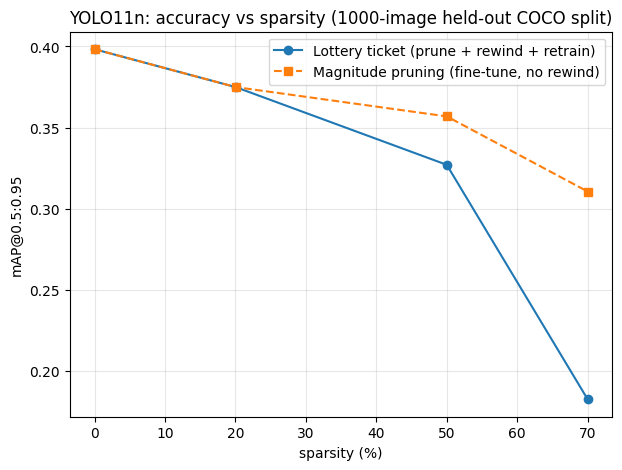

In [22]:
x_lth = [0] + [r["actual_sparsity"] * 100 for r in lth]
y_lth = [baseline_map] + [r["mAP50-95"] for r in lth]
x_mag = [0] + [r["actual_sparsity"] * 100 for r in magnitude]
y_mag = [baseline_map] + [r["mAP50-95"] for r in magnitude]

plt.figure(figsize=(7, 5))
plt.plot(x_lth, y_lth, "o-", label="Lottery ticket (prune + rewind + retrain)")
plt.plot(x_mag, y_mag, "s--", label="Magnitude pruning (fine-tune, no rewind)")
plt.xlabel("sparsity (%)")
plt.ylabel("mAP@0.5:0.95")
plt.title("YOLO11n: accuracy vs sparsity (1000-image held-out COCO split)")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(f"{OUT}/pruning_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Q12 — Transfer task: low-light indoor deployment

Testing 2 of the 5 models. Selected YOLO11n (Q3 winner, already
optimised) and RT-DETR-R18 (best small-object recall in Q1: 12 detections including
all three traffic lights, vs YOLO11n's 8 with none). Evaluated on the same 1000-image
held-out split, darkened to 0.25x gain.

In [36]:
ROOTD = "/content/datasets/coco"
GAIN = 0.25          # ~2 stops under-exposed, a realistic indoor-at-night level

paths = [p.replace("./", ROOTD + "/") for p in open(f"{ROOTD}/lth_eval.txt").read().split()]
dark_dir = f"{ROOTD}/images/val2017_dark"
os.makedirs(dark_dir, exist_ok=True)

for p in paths:
    img = cv2.imread(p).astype(np.float32)
    dark = np.clip(img * GAIN, 0, 255).astype(np.uint8)
    cv2.imwrite(f"{dark_dir}/{Path(p).name}", dark)

# ultralytics finds labels by swapping /images/ -> /labels/, so point the dark set at the same labels
if not os.path.exists(f"{ROOTD}/labels/val2017_dark"):
    os.symlink(f"{ROOTD}/labels/val2017", f"{ROOTD}/labels/val2017_dark")

with open(f"{ROOTD}/dark_eval.txt", "w") as f:
    f.write("\n".join(f"./images/val2017_dark/{Path(p).name}" for p in paths))

cfg = yaml.safe_load(open(ROOT / "cfg/datasets/coco.yaml"))
cfg["val"] = "dark_eval.txt"
yaml.safe_dump(cfg, open("/content/coco_dark.yaml", "w"))

print(len(paths), "images darkened at gain", GAIN)


1000 images darkened at gain 0.25


In [37]:
y_norm = YOLO("yolo11n.pt").val(data="/content/coco_lth.yaml",  verbose=False)
y_dark = YOLO("yolo11n.pt").val(data="/content/coco_dark.yaml", verbose=False)
print(f"YOLO11n  normal {y_norm.box.map:.4f}   dark {y_dark.box.map:.4f}")


YOLO11n  normal 0.3983   dark 0.3693


In [38]:
coco_gt = COCO(f"{ROOTD}/annotations/instances_val2017.json")
cat_ids = sorted(coco_gt.getCatIds())      # RT-DETR labels are 0-79; COCO json uses the 90-id space

proc = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_r18vd")
rtdetr = RTDetrForObjectDetection.from_pretrained("PekingU/rtdetr_r18vd").eval().cuda()

def rtdetr_eval(image_paths):
    dets, lat = [], []
    for p in image_paths:
        img = Image.open(p).convert("RGB")
        inp = proc(images=img, return_tensors="pt").to("cuda")

        start = time.perf_counter()
        with torch.no_grad():
            out = rtdetr(**inp)
        torch.cuda.synchronize()
        lat.append((time.perf_counter() - start) * 1000)

        sizes = torch.tensor([img.size[::-1]]).cuda()
        r = proc.post_process_object_detection(out, target_sizes=sizes, threshold=0.001)[0]

        keep = r["scores"].argsort(descending=True)[:100]      # COCO protocol: maxDets=100
        img_id = int(Path(p).stem)
        for s, l, b in zip(r["scores"][keep], r["labels"][keep], r["boxes"][keep]):
            x1, y1, x2, y2 = b.tolist()
            dets.append({"image_id": img_id, "category_id": cat_ids[int(l)],
                         "bbox": [x1, y1, x2 - x1, y2 - y1], "score": float(s)})

    e = COCOeval(coco_gt, coco_gt.loadRes(dets), "bbox")
    e.params.imgIds = [int(Path(p).stem) for p in image_paths]
    e.evaluate(); e.accumulate(); e.summarize()
    return e.stats[0], float(np.mean(lat))

dark_paths = [f"{dark_dir}/{Path(p).name}" for p in paths]
r_norm_map, r_norm_lat = rtdetr_eval(paths)
r_dark_map, r_dark_lat = rtdetr_eval(dark_paths)


loading annotations into memory...
Done (t=0.45s)
creating index...
index created!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 80.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.10s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.47s).
Accumulating evaluation results...
DONE (t=1.94s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.475
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.644
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.517
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.325
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.520
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.637
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.359
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.596
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.642
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [39]:
base = results["yolo11n_baseline"]

q12 = pd.DataFrame([
    {"model": "YOLO11n",     "mAP normal": y_norm.box.map, "mAP dark": y_dark.box.map,
     "latency_ms": base["latency_ms"], "FPS": base["fps"]},
    {"model": "RT-DETR-R18", "mAP normal": r_norm_map,     "mAP dark": r_dark_map,
     "latency_ms": r_dark_lat,         "FPS": 1000 / r_dark_lat},
]).assign(drop_pct=lambda d: 100 * (1 - d["mAP dark"] / d["mAP normal"]))

# YOLO11n latency is the Q5 baseline measurement; inference cost does not depend on
# image brightness, only the accuracy does.
for row in q12.to_dict("records"):
    tag = "yolo11n_lowlight" if row["model"] == "YOLO11n" else "rtdetr_r18_lowlight"
    run = wandb.init(project="edge-vision-yolo11n", name=tag, reinit=True)
    wandb.log({k: v for k, v in row.items() if k != "model"})
    run.finish()

q12.round(4)


,model,mAP normal,mAP dark,latency_ms,FPS,drop_pct
0,YOLO11n,0.3983,0.3693,15.9000,62.9000,7.2894
1,RT-DETR-R18,0.4750,0.4377,30.9431,32.3174,7.8504


## Save results

Run after each question so a runtime disconnect costs one section rather than all of them.

In [28]:
def save():
    payload = {k: v for k, v in {
        "variants": globals().get("results"),
        "lth": globals().get("lth"),
        "magnitude": globals().get("magnitude"),
        "hybrid": globals().get("hybrid"),
        "control": globals().get("control"),
        "focal": globals().get("focal"),
        "bce": globals().get("bce"),
        "baseline_map": globals().get("baseline_map"),
    }.items() if v is not None}

    json.dump(payload, open(f"{OUT}/results.json", "w"), indent=2, default=str)
    for f in ["yolo11n-aifi.yaml", "yolo11n_fp16.engine", "yolo11n_int8.engine"]:
        if os.path.exists(f):
            shutil.copy(f, OUT)
    print("saved:", sorted(payload), "->", OUT)

save()

saved: ['baseline_map', 'bce', 'control', 'focal', 'hybrid', 'lth', 'magnitude'] -> /content/drive/MyDrive/edge_vision
